SALES PREDICTION USING PYTHON

Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

sns.set_style("whitegrid")

Load Dataset

In [2]:
df = pd.read_csv("advertising.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (200, 4)


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


Data Cleaning

In [3]:
print("Missing Values\n")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("\nFinal Shape:", df.shape)

df.info()

Missing Values

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Duplicate Rows: 0

Final Shape: (200, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


Visualization

Sales Distribution

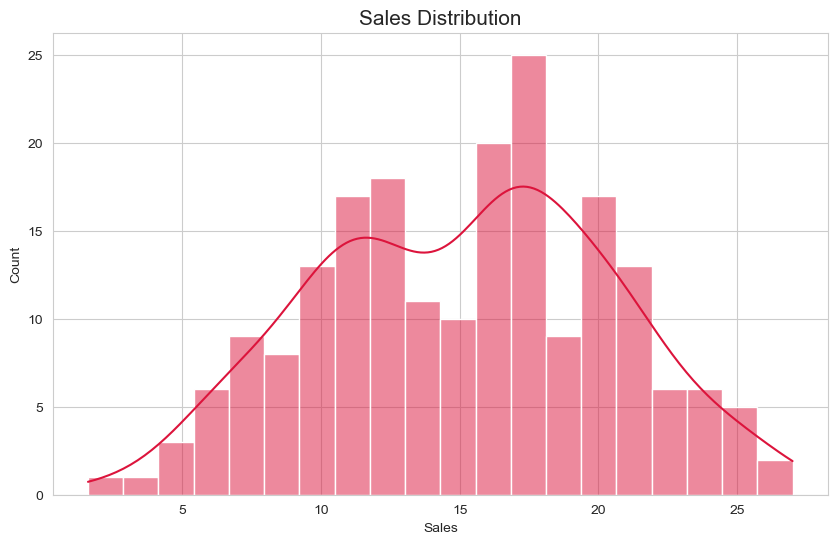

In [4]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Sales'],
    bins=20,
    kde=True,
    color='crimson'
)

plt.title("Sales Distribution", fontsize=15)

plt.show()

TV Advertising vs Sales

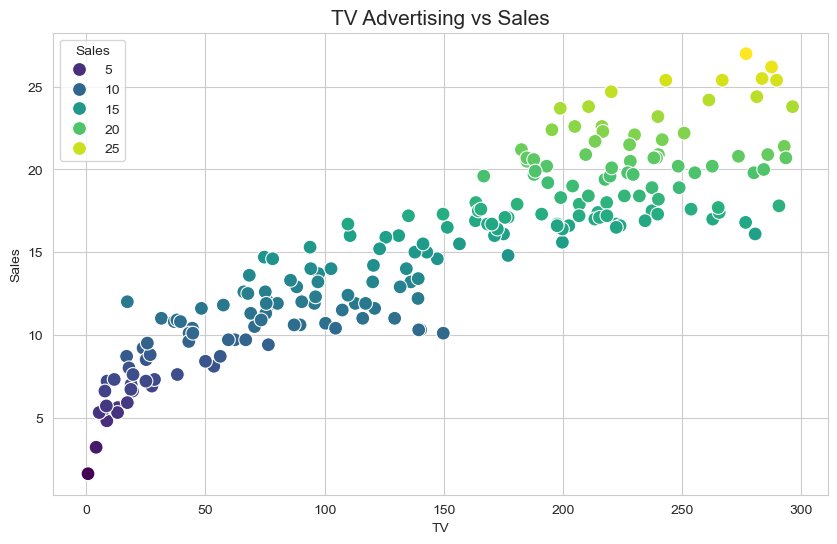

In [5]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='TV',
    y='Sales',
    hue='Sales',
    palette='viridis',
    s=100
)

plt.title("TV Advertising vs Sales", fontsize=15)

plt.show()

Correlation Heatmap

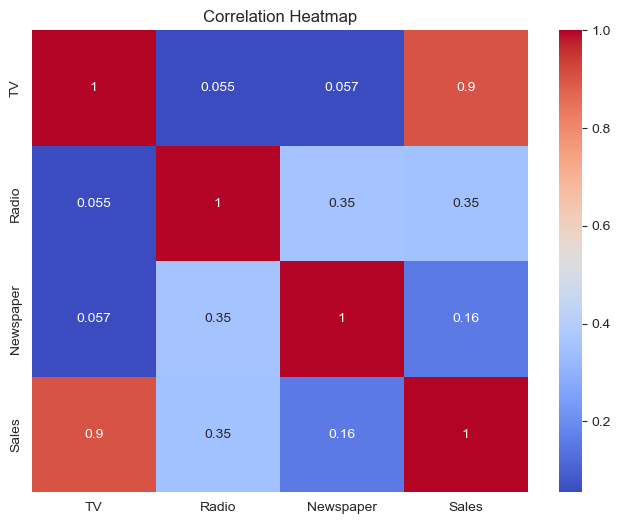

In [6]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

Features and Target

In [7]:
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

Train Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Train Model

In [9]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


Prediction

In [10]:
y_pred = model.predict(X_test)
print("Prediction Completed")

Prediction Completed


Model Evaluation

In [11]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae,3))
print("RMSE:", round(rmse,3))
print("R² Score:", round(r2,3))

MAE : 1.275
RMSE: 1.705
R² Score: 0.906


Actual vs Predicted Sales

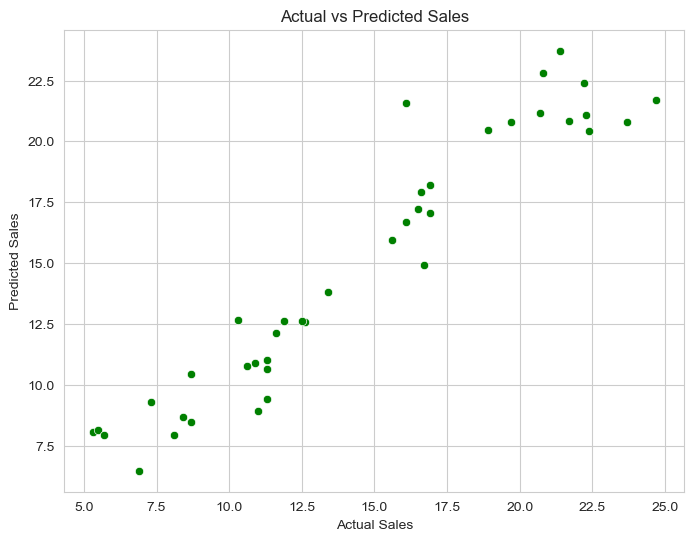

In [12]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_test,
    y=y_pred,
    color='green'
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

Feature Importance

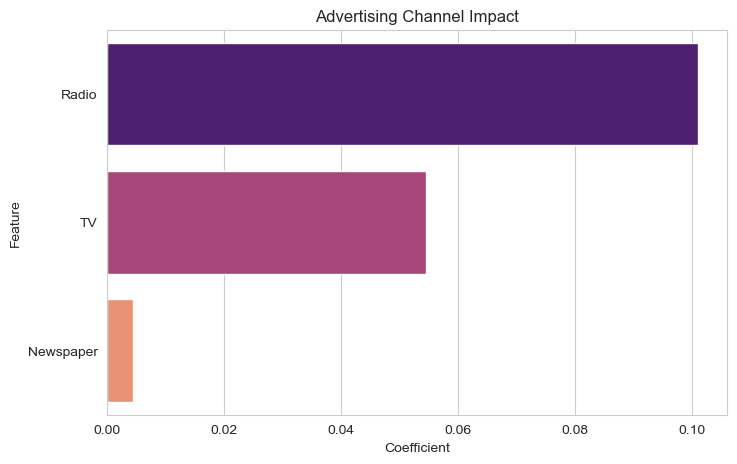

In [13]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x='Coefficient',
    y='Feature',
    hue='Feature',
    palette='magma',
    legend=False
)

plt.title("Advertising Channel Impact")

plt.show()